In [1]:
# Homework 3 code

import cv2 as cv
import numpy as np
import os
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "Fish"

dataset = keras.utils.image_dataset_from_directory(
    directory=DATA_PATH,
    validation_split=0.30,
    subset="both",
    seed=67,
    image_size=(128, 128), # Part 2 req
    batch_size=32
)


Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.


2026-07-18 12:52:36.301375: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-07-18 12:52:36.301545: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-18 12:52:36.301564: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-18 12:52:36.301816: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-18 12:52:36.301832: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
train_set = dataset[0]
remaining = dataset[1]

# remaining has 30% so cutting it into 2
remaining_set = tf.data.experimental.cardinality(remaining)

val_set = remaining.take(remaining_set // 2)
test_set = remaining.skip(remaining_set // 2)


In [4]:
class_names = train_set.class_names

In [5]:
from keras import layers

data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(.2),
    layers.RandomBrightness(.3)
])

In [6]:
model = keras.Sequential([
    data_aug,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=20
)

Epoch 1/20


/Users/minhtran/Desktop/College stuff/9th Semester (Summer 2026)/Computer Vision Project/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-18 12:52:37.019339: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3062 - loss: 1.7285 - val_accuracy: 0.4500 - val_loss: 1.3230
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4705 - loss: 1.3464 - val_accuracy: 0.5063 - val_loss: 1.2273
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5393 - loss: 1.2374 - val_accuracy: 0.5063 - val_loss: 1.4441
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5913 - loss: 1.1436 - val_accuracy: 0.6500 - val_loss: 1.0035
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6447 - loss: 0.9877 - val_accuracy: 0.6438 - val_loss: 1.1271
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6601 - loss: 0.9158 - val_accuracy: 0.5938 - val_loss: 0.9256
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6587 - loss: 0.8981 - val_accuracy: 0.6687 - val_loss: 0.9350
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7079 - loss: 0.7818 - val_accuracy: 0.7375 - val_loss: 0.

In [9]:
model.save("baseline.keras")

In [10]:
test_loss, test_acc = model.evaluate(test_set)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8403 - loss: 0.4321


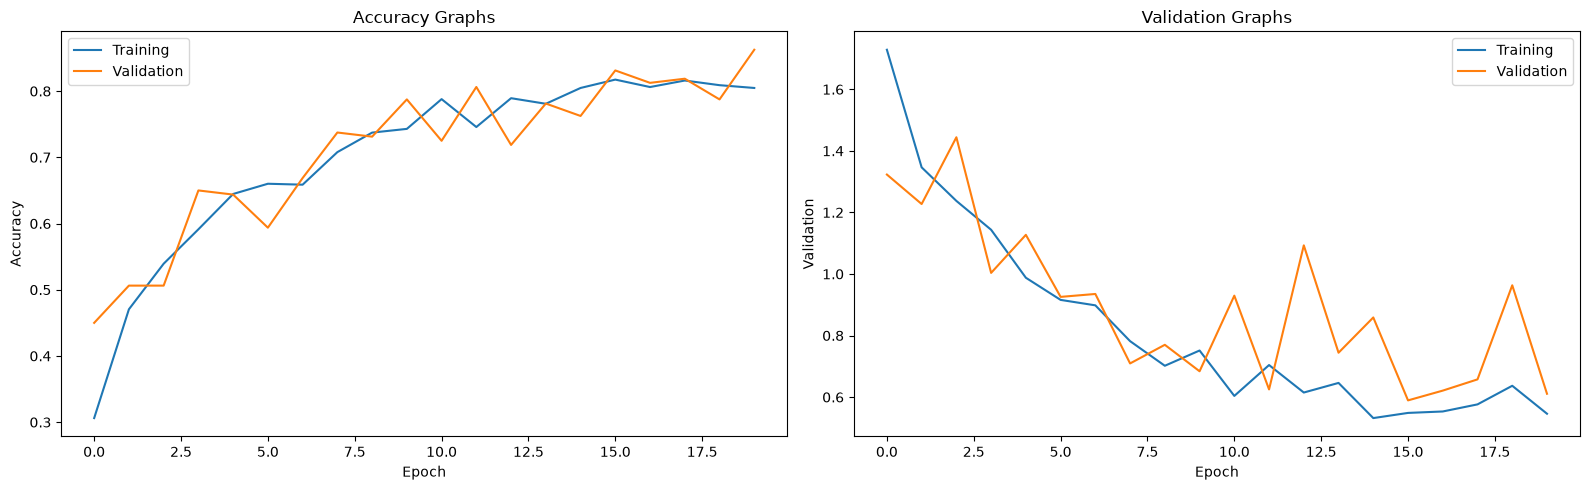

In [11]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs")

plt.tight_layout()
plt.show()

In [12]:
# helper funcs for the grid search

def dataset(batch_size, path):
    dataset = keras.utils.image_dataset_from_directory(
        directory=path,
        validation_split=0.30,
        subset="both",
        seed=67,
        image_size=(128, 128),
        batch_size=batch_size
    )
    train_set = dataset[0]
    remaining = dataset[1]
    remaining_set = tf.data.experimental.cardinality(remaining)
    val_set = remaining.take(remaining_set // 2)
    test_set = remaining.skip(remaining_set // 2)

    return train_set, val_set, test_set

def model(dropout, data_aug):
    model = keras.Sequential([
        data_aug,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.Dense(6, activation='softmax')
    ])
    return model

In [13]:
# Part 4

learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64]
dropouts = [0.3, 0.5]

best_val_acc = 0
best_val_loss = float(10000.00)
best_history = None
best_params = None
best_model = None

model_history = []

for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        for dropout in dropouts:
            train_set, val_set, test_set = dataset(batch_size, DATA_PATH)
            grid_model = model(dropout, data_aug)

            grid_model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )

            history = grid_model.fit(
                train_set,
                validation_data=val_set,
                epochs=35
            )

            val_acc = max(history.history["val_accuracy"])
            val_loss = max(history.history["val_loss"])
            train_acc = max(history.history["accuracy"])
            train_loss = max(history.history["loss"])
            params = (learning_rate, batch_size, dropout)
            if val_loss < best_val_loss:
                best_val_acc = val_acc
                best_val_loss = val_loss
                best_history = history
                best_params = params
                best_model = grid_model

            model_history.append((params, val_acc, train_acc, val_loss, train_loss))

            

best_model.save("best_model.keras")

Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.
Epoch 1/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2065 - loss: 2.5516 - val_accuracy: 0.2375 - val_loss: 1.7841
Epoch 2/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2093 - loss: 2.2063 - val_accuracy: 0.1875 - val_loss: 2.1241
Epoch 3/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2331 - loss: 1.8547 - val_accuracy: 0.2375 - val_loss: 1.7749
Epoch 4/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3006 - loss: 1.6974 - val_accuracy: 0.2937 - val_loss: 1.7500
Epoch 5/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3413 - loss: 1.6614 - val_accuracy: 0.4563 - val_loss: 1.5089
Epoch 6/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3778 - loss: 1.5647 - val_accuracy: 0.4875 - val_loss: 1.6125
Epoch 7/35
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3511 - loss: 1.7228 - val_accuracy: 0.4437 - val_loss: 1.4519
Epoch 8/

Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
              precision    recall  f1-score   support

        Bete       0.88      0.54      0.67        41
        Cray       0.60      0.86      0.71         7
     Discuss       0.90      1.00      0.95        36
        Gold       1.00      0.78      0.87        40
       Guppy       0.83      0.94      0.88        32
       Oscar       0.50      0.85      0.63        20

    accuracy                           0.81       176
   macro avg       0.79      0.83      0.78       176
weighted avg       0.85      0.81      0.81       176

Bete: 0.537
Cray: 0.857
Discuss: 1.000
Gold: 0.775
Guppy: 0.938
Oscar: 0.850


2026-07-18 12:59:03.043137: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


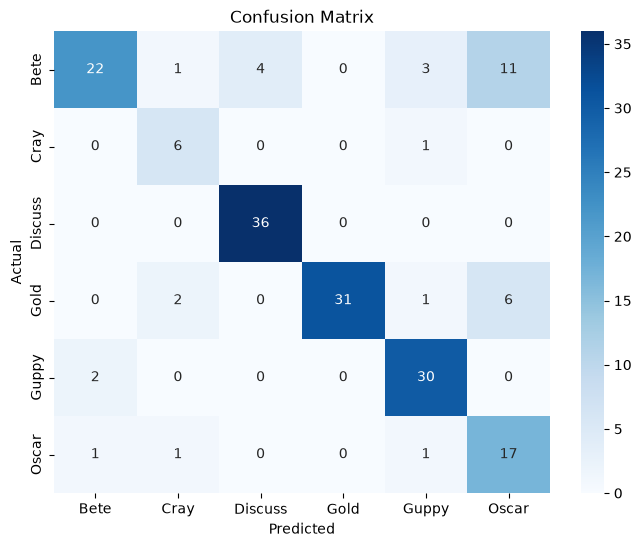

In [14]:
# Part 5

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

best_batch = best_params[1]
grid_train_ds, grid_val_ds, grid_test_ds = dataset(best_batch, DATA_PATH)

pred = best_model.predict(grid_test_ds)

y_pred = np.argmax(pred, axis=1)

y_true = np.concatenate([y for x, y in grid_test_ds])

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for name, acc in zip(class_names, class_accuracy):
    print(f"{name}: {acc:.3f}")

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

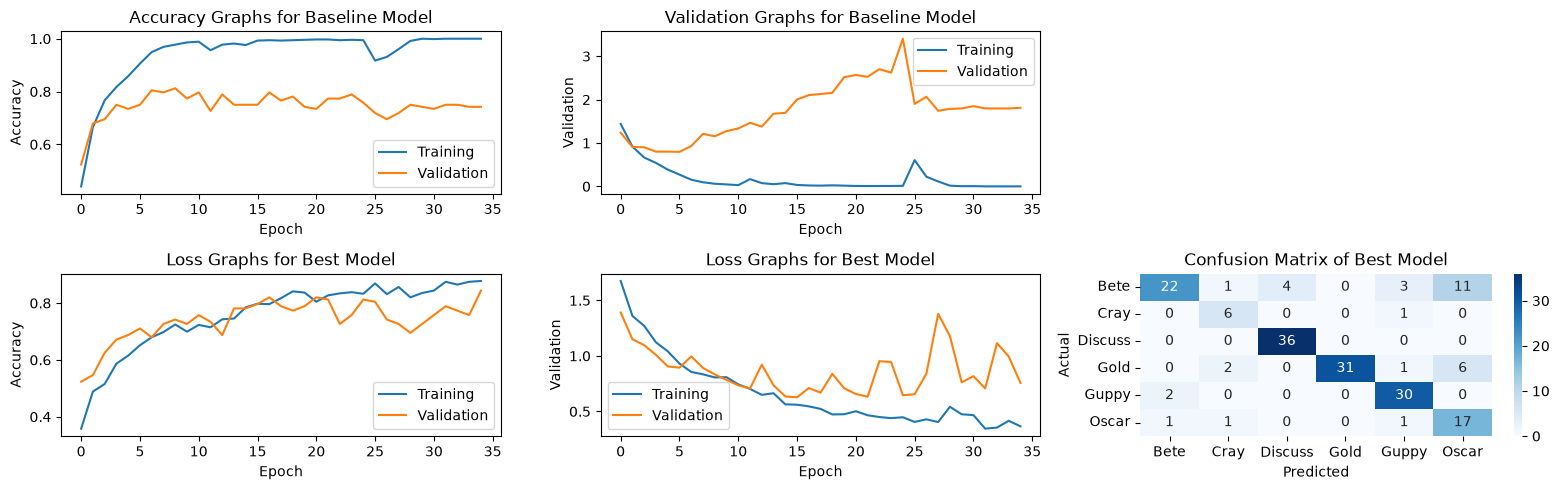

In [22]:
plt.figure(figsize=(16,5))

#baseline
plt.subplot(2,3,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy Graphs for Baseline Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,3,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Validation Graphs for Baseline Model")

#confusion matrix
plt.subplot(2,3,6)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix of Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

#best

plt.subplot(2,3,4)
plt.plot(best_history.history["accuracy"], label="Training")
plt.plot(best_history.history["val_accuracy"], label="Validation")
plt.title("Loss Graphs for Best Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2,3,5)
plt.plot(best_history.history["loss"], label="Training")
plt.plot(best_history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("Loss Graphs for Best Model")

plt.tight_layout()
plt.show()

In [18]:
for model_ in model_history:
    print(f"Learning Rate: {model_[0][0]} | Batch Size: {model_[0][1]}| Dropout: {model_[0][2]} | val accuracy: {model_[1]:.4f} | train accuracy: {model_[2]:.4f} | val loss: {model_[3]:.4f} | train loss: {model_[4]:.4f}")

Learning Rate: 0.01 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.5188 | train accuracy: 0.4621 | val loss: 135.5290 | train loss: 50.4238
Learning Rate: 0.01 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.2250 | train accuracy: 0.2261 | val loss: 2.0361 | train loss: 3.4246
Learning Rate: 0.01 | Batch Size: 64| Dropout: 0.3 | val accuracy: 0.2500 | train accuracy: 0.2037 | val loss: 2.2784 | train loss: 7.2143
Learning Rate: 0.01 | Batch Size: 64| Dropout: 0.5 | val accuracy: 0.5547 | train accuracy: 0.4817 | val loss: 5.2555 | train loss: 8.5700
Learning Rate: 0.001 | Batch Size: 32| Dropout: 0.3 | val accuracy: 0.8375 | train accuracy: 0.8694 | val loss: 1.4792 | train loss: 1.7340
Learning Rate: 0.001 | Batch Size: 32| Dropout: 0.5 | val accuracy: 0.8250 | train accuracy: 0.8399 | val loss: 1.5575 | train loss: 1.9656
Learning Rate: 0.001 | Batch Size: 64| Dropout: 0.3 | val accuracy: 0.8438 | train accuracy: 0.8778 | val loss: 1.3905 | train loss: 1.6743
Learning Rate: 0.001 

In [17]:
print(best_params)

(0.001, 64, 0.3)


In [20]:
# Extra 

learning_rate = 0.001
batch_size = 64
dropout = .3


train_set, val_set, test_set = dataset(batch_size, DATA_PATH)

no_aug_model = keras.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

no_aug_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = no_aug_model.fit(
    train_set,
    validation_data=val_set,
    epochs=35
)

no_aug_model.save("no_aug_model.keras")
no_aug_model_history = no_aug_model.history

Found 1016 files belonging to 6 classes.
Using 712 files for training.
Using 304 files for validation.
Epoch 1/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4410 - loss: 1.4380 - val_accuracy: 0.5234 - val_loss: 1.2360
Epoch 2/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6657 - loss: 0.9155 - val_accuracy: 0.6797 - val_loss: 0.9078
Epoch 3/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7669 - loss: 0.6649 - val_accuracy: 0.6953 - val_loss: 0.9012
Epoch 4/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8174 - loss: 0.5404 - val_accuracy: 0.7500 - val_loss: 0.8008
Epoch 5/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8581 - loss: 0.3873 - val_accuracy: 0.7344 - val_loss: 0.8012
Epoch 6/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9059 - loss: 0.2719 - val_accuracy: 0.7500 - val_loss: 0.7961
Epoch 7/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9494 - loss: 0.1540 - val_accuracy: 0.8047 - val_loss: 0.9288
Epoch 8/

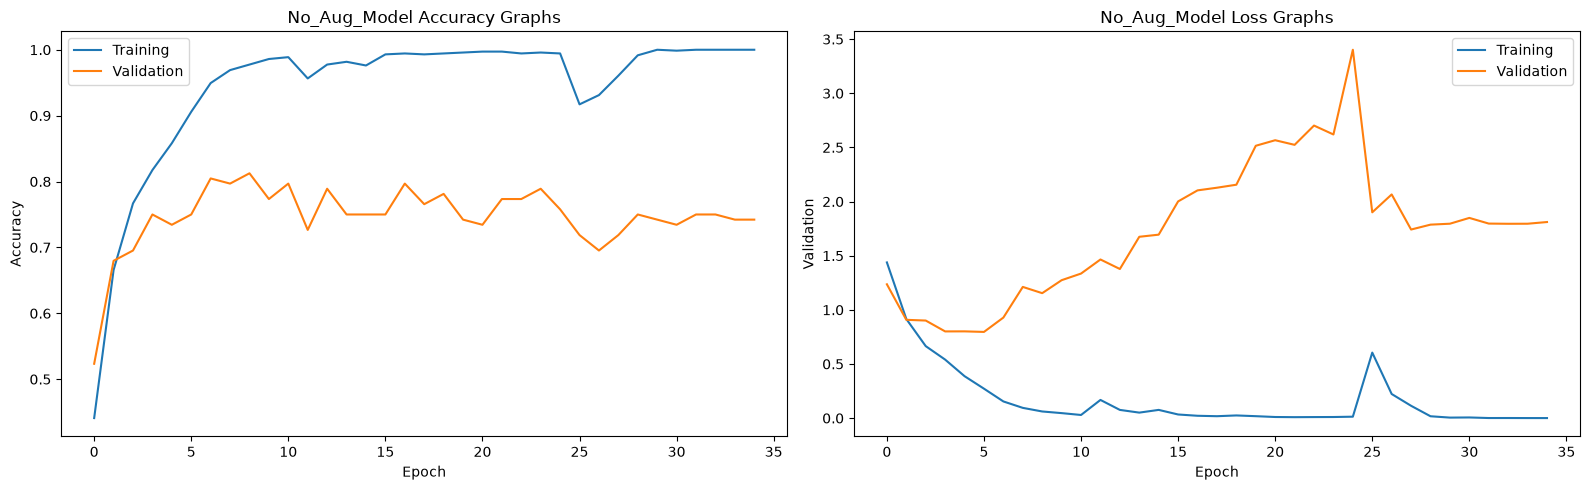

In [21]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("No_Aug_Model Accuracy Graphs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation")
plt.title("No_Aug_Model Loss Graphs")

plt.tight_layout()
plt.show()

In [23]:
val_acc = max(history.history["val_accuracy"])
val_loss = max(history.history["val_loss"])
train_acc = max(history.history["accuracy"])
train_loss = max(history.history["loss"])

print(f"Validation Accuracy: {val_acc}")
print(f"Validation Loss: {val_loss}")
print(f"Training Accuracy: {train_acc}")
print(f"Training Loss: {train_loss}")

Validation Accuracy: 0.8125
Validation Loss: 3.402238368988037
Training Accuracy: 1.0
Training Loss: 1.4379870891571045
